# Import Packages

In [6]:
import abm
import numpy as np
from plotnine import *
import pandas as pd

# Prepare simulations

## Load IQ Design Model File

In [7]:
model = 'inputs/Models/2compartment_Ab.iqd'

## Load Nominal Parameter File

In [8]:
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

## Set up Custom Dosing

In [9]:
doses = [0.1, 0.3, 1, 3, 10, 30]
times = [0, 7, 14, 21, 28]

TdosIV = pd.DataFrame({'dose_mpk':doses,
                       'amounts':doses,
                       'times':[times] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg', route = 'Dose_IV')
TdosSC = pd.DataFrame({'dose_mpk':doses,
                       'amounts':doses,
                       'times':[times] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg', route = 'Dose_SC')

Tdos = pd.concat([TdosIV, TdosSC])

Tsim = Tdos[['dose_mpk', 'route']]

Tpar2 = Tpar.copy()
Tpar2 = pd.concat([Tpar, pd.DataFrame({'parameter':['Dose_amt_IV', 'Dose_amt_SC']}).assign(unit = 'mg/kg', value = 0, is_fit = False)])

# Simulate Model
## Nominal Case

In [10]:
Tnominal = abm.simulate(models = model,
                        outputs = ['free_drug_c', 'RO_c'],
                        doses = Tdos,
                        simulations = Tsim,
                        parameters = Tpar2,
                        times = abm.linspace(0,35,351, 'd')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

/home/jovyan/environment/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


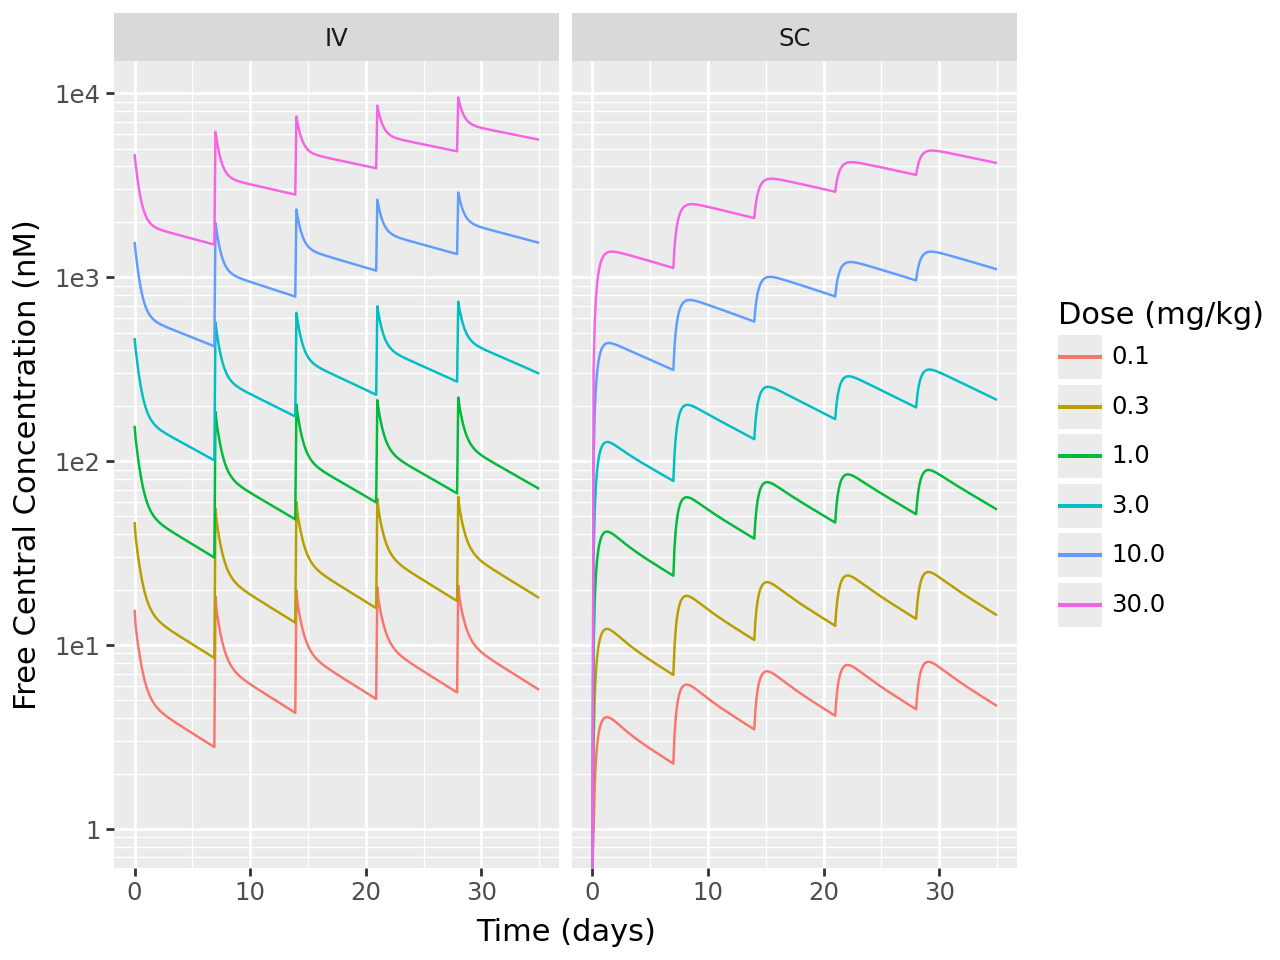

In [11]:
# PK plot - log axis
fig_PK = (ggplot()
          + geom_line(data = Tnominal.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
          + labs(x = 'Time (days)', y = 'Free Central Concentration (nM)', color = 'Dose (mg/kg)')
          + facet_wrap('route', labeller = lambda x: x.split('_')[1])
          + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
         )

display(fig_PK)

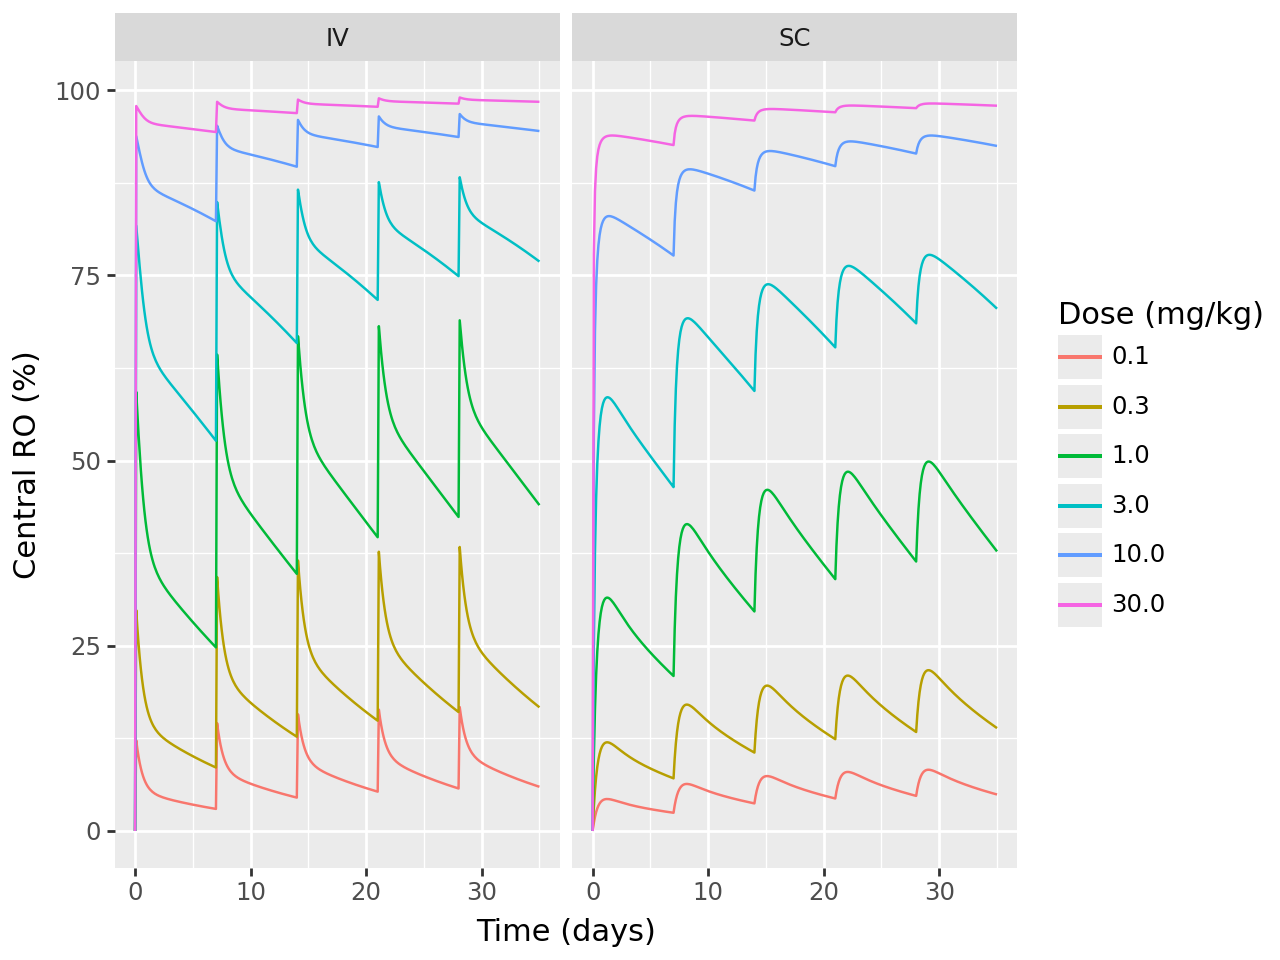

In [12]:
# RO plot - linear axis
fig_RO = (ggplot()
          + geom_line(data = Tnominal.query('output == "RO_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
          + labs(x = 'Time (days)', y = 'Central RO (%)', color = 'Dose (mg/kg)')
          + facet_wrap('route', labeller = lambda x: x.split('_')[1])
         )

display(fig_RO)

## Simulate Parameter Scans

In [13]:
display(Tpar)

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
4,Pdist,1,0.300,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
6,Thalf,d,28.000,False,NaN,NaN
7,Receptors_c,nM,10.000,False,NaN,NaN
8,Receptors_p,nM,50.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN


### Select example dose (1 mg/kg) and route (IV)

In [14]:
Tsim_sub = Tsim.query('route == "Dose_IV" and dose_mpk == 3')

In [15]:
display(Tsim_sub)

,dose_mpk,route
3,3.0,Dose_IV


### Single Parameter PK sensitivity
Scan over central Receptor density, drug half life, and drug affinity

In [16]:
Tscan1 = abm.simulate(models = model,
                      outputs = ['free_drug_c', 'RO_c'],
                      doses = Tdos,
                      simulations = Tsim_sub,
                      parameters = Tpar2,
                      scans = abm.fold_scan(Receptors_c = [0.5,1,2])
                              + abm.fold_scan(Thalf = [0.5,1,2])
                              + abm.fold_scan(Kd = [0.5,1,2]),
                      times = abm.linspace(0,35,351, 'd')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [17]:
display(Tscan1.head())

,dose_mpk,route,scan_0_type,id,param_scan_0,scan_0_value,scan_0_fold,t,output,value,output_unit
0,3.0,Dose_IV,fold,0,Receptors_c,5.0,0.5,0.0,free_drug_c,466.666667,nM
1,3.0,Dose_IV,fold,0,Receptors_c,5.0,0.5,0.0,RO_c,0.000000,1
2,3.0,Dose_IV,fold,0,Receptors_c,5.0,0.5,0.1,free_drug_c,405.209511,nM
3,3.0,Dose_IV,fold,0,Receptors_c,5.0,0.5,0.1,RO_c,81.825786,1
4,3.0,Dose_IV,fold,0,Receptors_c,5.0,0.5,0.2,free_drug_c,358.556649,nM


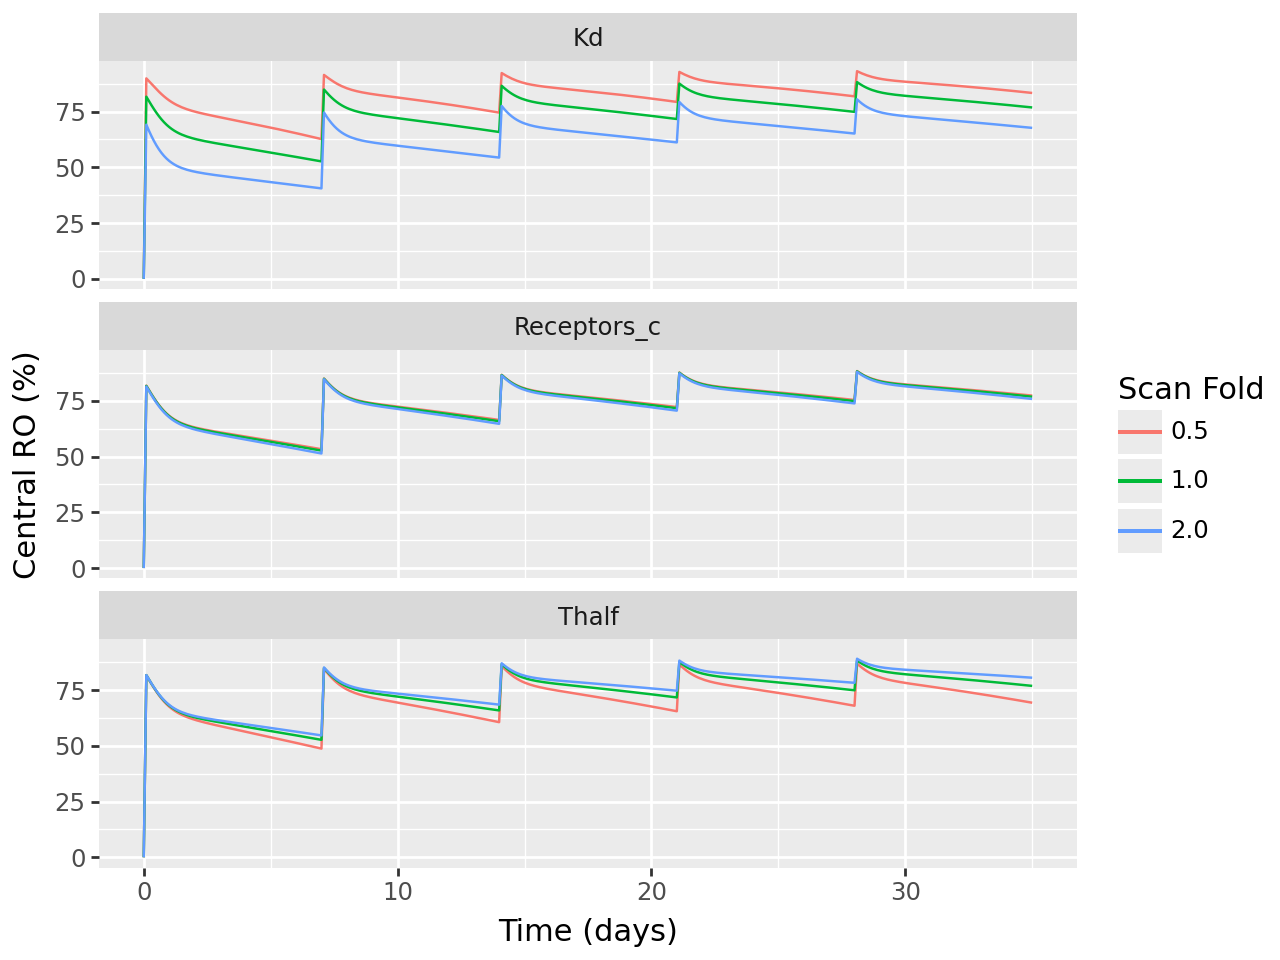

In [18]:
# RO plot - linear axis
fig_RO_scan = (ggplot()
          + geom_line(data = Tscan1.query('output == "RO_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(scan_0_fold)'))
          + labs(x = 'Time (days)', y = 'Central RO (%)', color = 'Scan Fold')
          + facet_wrap('param_scan_0', ncol = 1)
         )

display(fig_RO_scan)

### Two parameter PK sensitivity
Scan affinity and drug half life together - may be used when comparing different drugs

Create two cases:

1. Kd = 60 nM, Thalf = 14 d
2. Kd = 100 nM, Thalf = 30 d

In [19]:
Tscan2 = abm.simulate(models = model,
                      outputs = ['free_drug_c', 'RO_c'],
                      doses = Tdos,
                      simulations = Tsim_sub,
                      parameters = Tpar2,
                      scans = abm.value_scan(Kd = ['60:nM', '100:nM'], Thalf = ['14:d','30:d']),
                      times = abm.linspace(0,35,351, 'd')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [20]:
Tscan2['label'] = Tscan2.apply(lambda x: f'KD = {x.scan_0_value}nM, Thalf = {x.scan_1_value}d', axis = 1)

In [21]:
Tscan2.head()

,dose_mpk,route,scan_0_type,scan_1_type,id,param_scan_0,scan_0_value,scan_0_fold,param_scan_1,scan_1_value,scan_1_fold,t,output,value,output_unit,label
0,3.0,Dose_IV,value,value,0,Kd,60.0,0.666667,Thalf,14.0,0.5,0.0,free_drug_c,466.666667,nM,"KD = 60.0nM, Thalf = 14.0d"
1,3.0,Dose_IV,value,value,0,Kd,60.0,0.666667,Thalf,14.0,0.5,0.0,RO_c,0.000000,1,"KD = 60.0nM, Thalf = 14.0d"
2,3.0,Dose_IV,value,value,0,Kd,60.0,0.666667,Thalf,14.0,0.5,0.1,free_drug_c,399.812469,nM,"KD = 60.0nM, Thalf = 14.0d"
3,3.0,Dose_IV,value,value,0,Kd,60.0,0.666667,Thalf,14.0,0.5,0.1,RO_c,86.950970,1,"KD = 60.0nM, Thalf = 14.0d"
4,3.0,Dose_IV,value,value,0,Kd,60.0,0.666667,Thalf,14.0,0.5,0.2,free_drug_c,352.220079,nM,"KD = 60.0nM, Thalf = 14.0d"


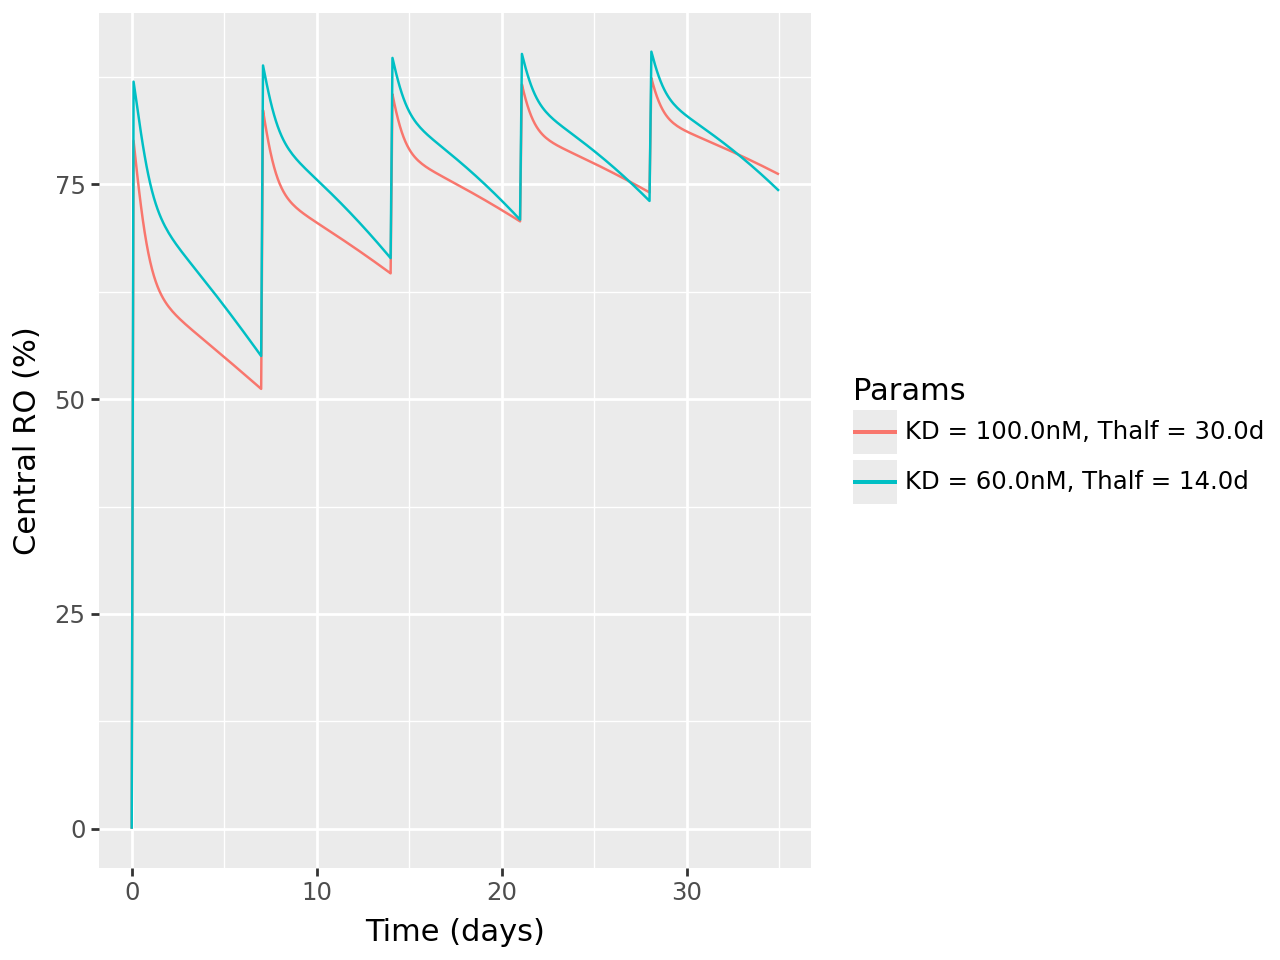

In [22]:
# RO plot - linear axis
fig_RO_2par = (ggplot()
          + geom_line(data = Tscan2.query('output == "RO_c"'), mapping = aes(x = 't', y = 'value', color = 'factor(label)'))
          + labs(x = 'Time (days)', y = 'Central RO (%)', color = 'Params')
         )

display(fig_RO_2par)

### PK parameter grid
Scan a range of affinity and half life values to see how those two parameters interact

Look at range of doses

In [23]:
Tscan3 = abm.simulate(models = model,
                      outputs = ['free_drug_c', 'RO_c'],
                      doses = Tdos,
                      simulations = Tsim,
                      parameters = Tpar2,
                      scans = abm.fold_scan(Kd = [0.1, 0.5, 1, 2, 10])
                              * abm.fold_scan(Thalf = [0.25, 0.5, 1, 2, 4]),
                      times = abm.linspace(0,35,351, 'd')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [24]:
Tscan3['Kd (nM)'] = Tscan3.apply(lambda x: int(x.scan_0_value), axis = 1)
Tscan3['Thalf (d)'] = Tscan3.apply(lambda x: int(x.scan_1_value), axis = 1)

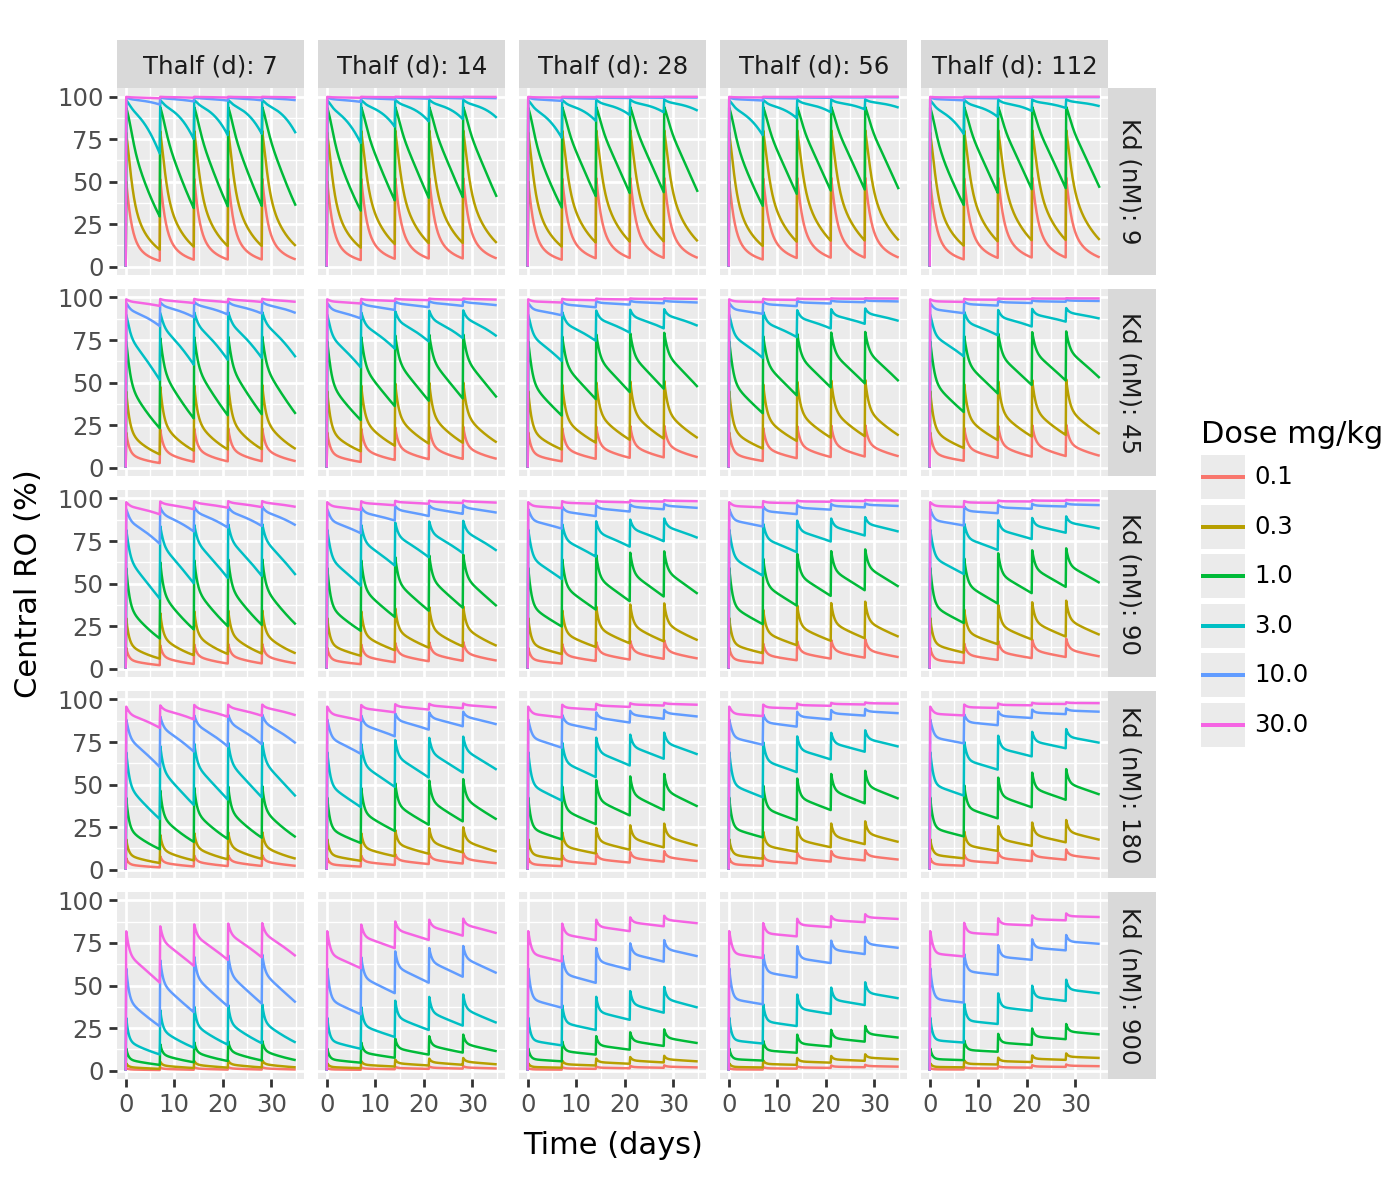

In [25]:
# RO plot - linear axis
fig_RO_grid = (ggplot()
          + geom_line(data = Tscan3.query('output == "RO_c" and route == "Dose_IV"'),
                      mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
          + labs(x = 'Time (days)', y = 'Central RO (%)', color = 'Dose mg/kg')
          + facet_grid('Kd (nM) ~ Thalf (d)', labeller = 'label_both')
          + theme(aspect_ratio = 1, figure_size = (7,6))
         )

display(fig_RO_grid)

### Tornado Plot

For a tornado plot, output Trough RO following final dose. Compare sensitivity at trough RO for two fold change in each parameter

In [26]:
Tpar

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
4,Pdist,1,0.300,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
6,Thalf,d,28.000,False,NaN,NaN
7,Receptors_c,nM,10.000,False,NaN,NaN
8,Receptors_p,nM,50.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN


In [27]:
Tscan4 = abm.simulate(models = model,
                      outputs = ['RO_c'],
                      doses = Tdos,
                      simulations = Tsim_sub,
                      parameters = Tpar2,
                      scans = abm.fold_scan(Volume_c = [0.5,1,2])
                              + abm.fold_scan(Volume_p = [0.5,1,2])
                              + abm.fold_scan(Pdist = [0.5,1,2])
                              + abm.fold_scan(Tdist = [0.5,1,2])
                              + abm.fold_scan(Thalf = [0.5,1,2])
                              + abm.fold_scan(Receptors_c = [0.5,1,2])
                              + abm.fold_scan(Receptors_p = [0.5,1,2])
                              + abm.fold_scan(kon = [0.5,1,2])
                              + abm.fold_scan(Thalf_R = [0.5,1,2])
                              + abm.fold_scan(Kd = [0.5,1,2])
                              + abm.fold_scan(Thalf_abs = [0.5,1,2]),
                      times = ['35:d']).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [28]:
Tscan4.head()

,dose_mpk,route,scan_0_type,id,param_scan_0,scan_0_value,scan_0_fold,t,output,value,output_unit
0,3.0,Dose_IV,fold,0,Volume_c,1.5,0.5,35.0,RO_c,79.859281,1
1,3.0,Dose_IV,fold,1,Volume_c,3.0,1.0,35.0,RO_c,76.852863,1
2,3.0,Dose_IV,fold,2,Volume_c,6.0,2.0,35.0,RO_c,71.588192,1
3,3.0,Dose_IV,fold,3,Volume_p,6.5,0.5,35.0,RO_c,86.230895,1
4,3.0,Dose_IV,fold,4,Volume_p,13.0,1.0,35.0,RO_c,76.852863,1


In [29]:
# Tornado Plot

# Get the nominal output value
nominal_value = Tscan4.value[Tscan4.scan_0_fold == 1.].unique()[0]

# Get table with parameters ordered as they should appear in the tornado plot
par_ranges = (
    Tscan4.groupby('param_scan_0') # For each parameter...
        ['value'] # ...take the value column...
        .apply(lambda val: max(val)-min(val)) # ...and calculate the difference between the max and min value
        .sort_values() # Sort parameters by the result
)
ordered_pars = par_ranges.index.tolist()

# Construct the plot
fig_tornado = (
    ggplot(Tscan4.query('scan_0_fold != 1'))
    
    # Colored segments connecting the points
    + geom_segment(aes(x='value', xend='nominal_value', y='param_scan_0', yend='param_scan_0', color = 'factor(scan_0_fold)'),
                   size = 10, alpha = 1)
    
    # Nominal line
    + geom_vline(xintercept = nominal_value)
    
    # Set colors and their labels
    + scale_color_manual(values = ['#E4312C', '#F8B028'],
                         labels = lambda xs: [f"{xi:g}x" for xi in xs] # Function converts list of numbers to "{number}x"
                        )
    
    # Order the parameters for the "tornado" shape
    + scale_y_discrete(limits = ordered_pars) # For a discrete scale, setting limits sets the order of values
    
    + labs(x = "Central Trough RO (%)", y = "Scan Parameters", color = "Scanned Multiplier",
           title = "Sensitivity analysis")
    + theme_bw()
    + theme(aspect_ratio = 1.3, dpi=150, figure_size = (5,4))
)

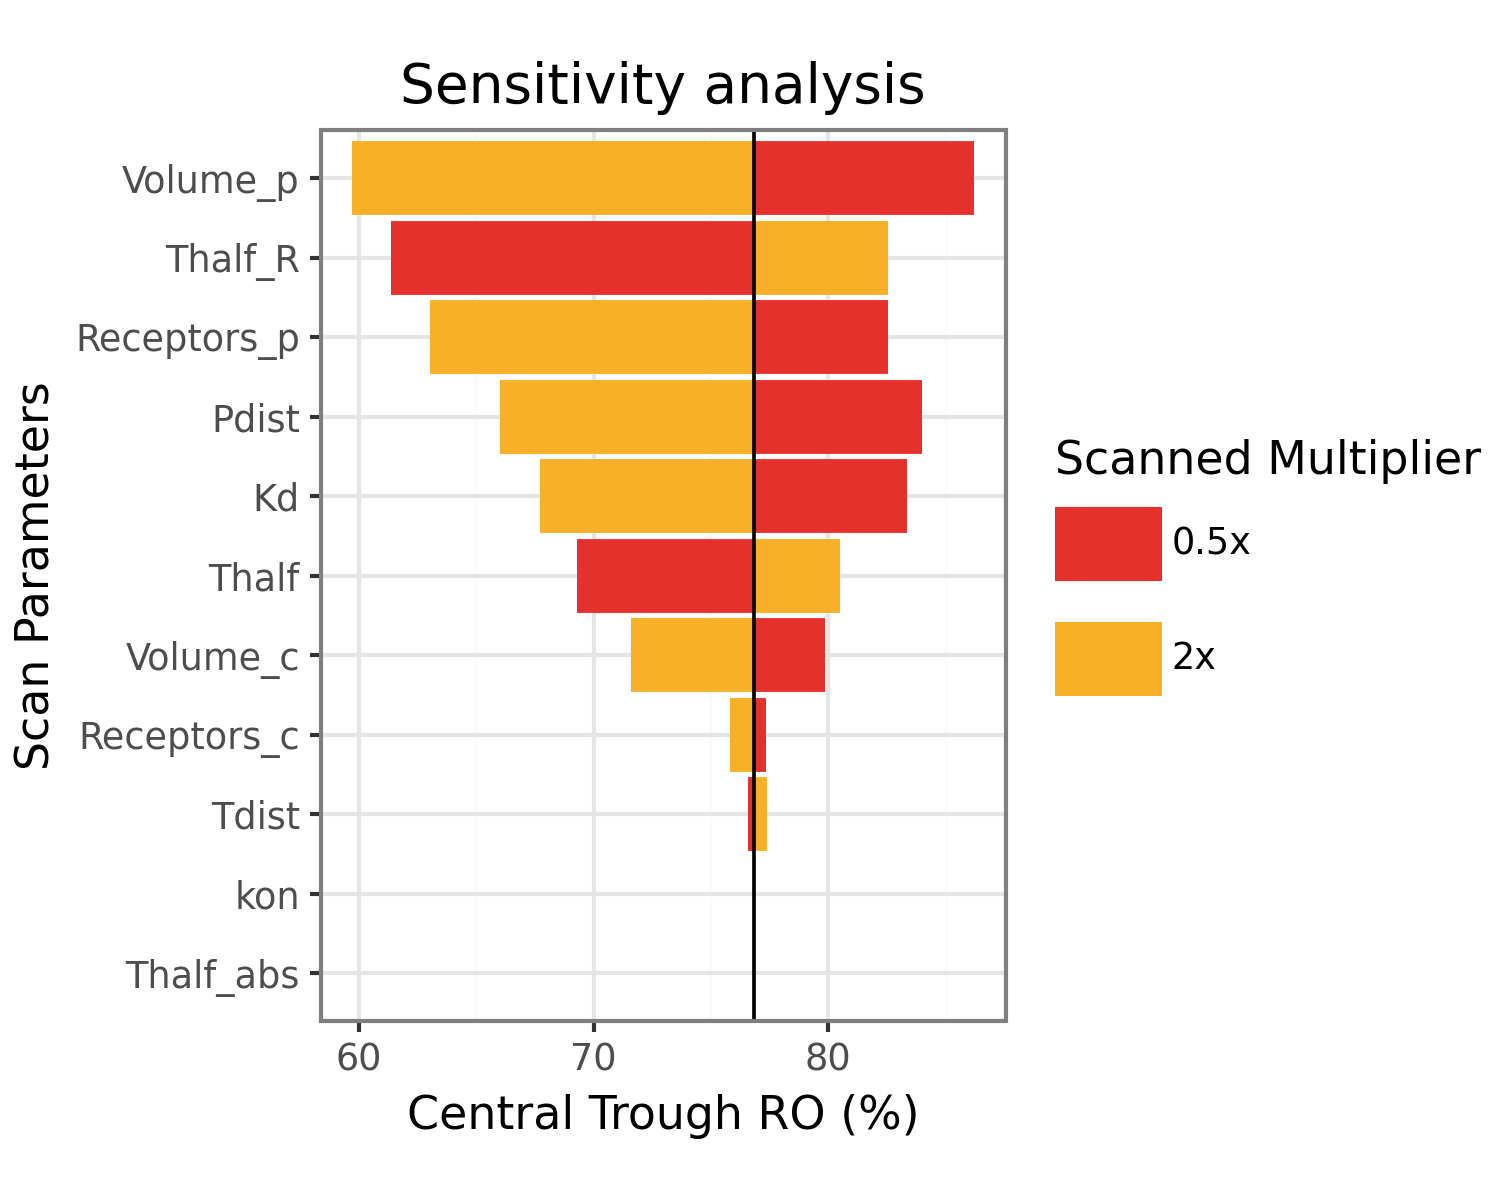

In [30]:
display(fig_tornado)